# **<span style="color: #c9a84c;">𓂀 Deliverable 2 - Dataset Exploration </span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

## <span style="color: #f0d080;">Contextual Sign Disambiguation: Moving from Sign Classification to Automated Sentence Translation</span>

<span style="color: #63ace0;">**CS437 / CS5317 / EE414 / EE513 - Deep Learning, Spring 2026**</span>

<span>**Authors:** 𓁐 Maryem Mahmood and Zehra Talat</span>

---

## **<span style="color: #c9a84c;">𓆣 Datasets</span>**

<span style="color: #a8c4d8;">This project uses two publicly documented datasets, merged into a single unified training corpus:</span>

| # | Dataset | Paper | Images | Classes | Notes |
|---|---|---|---|---|---|
| 1 | **Fuentes-Ferrer / EHT** | Fuentes-Ferrer et al., *Applied Soft Computing* 2025 | 9,703 (of 13,729 total) | 310 | Stone stelae, carved/painted |
| 2 | **Franken / OBC306** | Franken et al., *ACM Multimedia* 2013 | 4,210 | 171 | Pyramid of Unas, 10 wall photographs |
| - | **Glyph2025 (merged)** | Combined via EHT merge scripts | **13,287** | **352** | Deduplicated, lowercase-normalized |

<span style="color: #a8c4d8;">The merged **Glyph2025** dataset is used for all training and evaluation in this deliverable.</span>

---

## **<span style="color: #c9a84c;">𓆣 Deliverable Checklist</span>**

- <span style="color: #a8d8a8;"> Number of Classes Documented 𓂝 **Section 2**</span>
- <span style="color: #a8d8a8;"> Sample images with annotations 𓂝 **Section 3**</span>
- <span style="color: #a8d8a8;"> Train / Validation / Test splits 𓂝 **Section 4**</span>
- <span style="color: #a8d8a8;"> Data Leakage Verified 𓂝 **Section 4**</span>
- <span style="color: #a8d8a8;"> Custom Annotation 𓂝 Feature Enrichment 𓂝 **Section 5**</span>
- <span style="color: #a8d8a8;"> Class Imbalance 𓂝 Weighted Random Sampling 𓂝 **Section 6**</span>
- <span style="color: #a8d8a8;"> POC model + Accuracy reported 𓂝 **Section 7**</span>

<div style="width: 100%; text-align: center;">

<h1 style="color: #f0d080; font-size: 40px; font-weight: bold;">
    <span>𓅉 DECIPHERING THE PAST:
    <span style="color: #63ace0;">DEEP LEARNING EDITION</span></span>
</h1>

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">
</div>

<img src="epypt_pyramid.png" alt="Ancient Egyptian Temple" style="width: 100%; max-height: 500px; object-fit: cover; border: 2px solid #c9a84c;">

---

<p style="font-size: 18px; color: #e8d5a3;">
For over <b style="color: #f0d080;">3,000 years</b>, the ancient Egyptians carved their history, religion, and knowledge into stone walls, papyrus scrolls, and temple columns. Their writing system, <b style="color: #f0d080;">hieroglyphs</b>, is one of the most visually striking scripts ever devised by humanity, combining phonetic sounds, whole words, and semantic classifiers into a single unified system of over <b style="color: #63ace0;">700 distinct signs</b>.
</p>

<p style="font-size: 18px; color: #e8d5a3;">
Yet today, <b style="color: #f0d080;">thousands of inscribed artifacts remain untranslated</b>. The global shortage of trained Egyptologists means that vast stretches of human history - prayers, medical texts, royal decrees, love poems - sit silent on museum shelves and buried chamber walls. The knowledge encoded in those stones has waited millennia for someone to read it.
</p>

<p style="font-size: 18px; color: #e8d5a3;">
The challenge is not merely recognizing individual signs. A single hieroglyph can function as a <b style="color: #63ace0;">phonogram</b> (representing a sound), a <b style="color: #63ace0;">logogram</b> (representing a whole word), or a <b style="color: #63ace0;">determinative</b> (a silent classifier that tells you the category of the preceding word). The same bird 𓅓 carved into stone could mean the letter <i>m</i>, the word <i>owl</i>, or silently signal that the word before it belongs to the category of animals - depending entirely on <b style="color: #f0d080;">context</b>.
</p>

<p style="font-size: 18px; color: #e8d5a3;">
Current deep learning systems can <b style="color: #f0d080;">name</b> signs - but they cannot <b style="color: #f0d080;">read</b> them. They classify each hieroglyph in isolation, blind to the sequence of symbols surrounding it. This is the fundamental gap our project addresses. Inspired by the way <b style="color: #63ace0;">POS tagging</b> transformed low-resource NLP for languages like Urdu, we enrich each sign with its linguistic role and train an attention-based model to understand hieroglyphs not as isolated objects - but as a <b style="color: #f0d080;">living language</b>.
</p>

<p style="font-size: 18px; color: #e8d5a3;">
This is not just a computer vision problem. It is an act of <b style="color: #9d2e13;">resurrection</b> - giving voice back to the people who built the pyramids, sailed the Nile, and looked up at the same stars we see today. With every sign our model correctly reads, three thousand years of silence grows a little shorter.
</p>

<div style="width: 100%; text-align: center;">
<h1 style="color: #f0d080; font-size: 40px; font-weight: bold;">
    <span>𓄃 Let's Begin the Decipherment</span></span>
</h1>
<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">
</div>

In [12]:
from IPython.display import Audio

Audio(filename="/content/𝑰 𝑾𝒂𝒍𝒌 𝑶𝒏 𝒀𝒐𝒖𝒓 𝑾𝒂𝒕𝒆𝒓  𝘚𝘢𝘳𝘢𝘩 𝘚𝘤𝘩𝘢𝘤𝘩𝘯𝘦𝘳  𝙨𝙡𝙤𝙬𝙚𝙙  𝘈𝘊 𝘖𝘳𝘪𝘨𝘪𝘯𝘴 𝘖𝘚𝘛.mp3")


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **<span style="color: #c9a84c;">𓄄 Section 0 - Environment Setup</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

In [14]:
import os, json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu128


# **<span style="color: #c9a84c;">𓄄 Section 1 - Dataset Acquisition</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We build our dataset from two sources, merged into a single unified folder <b style="color: #f0d080;">Glyph2025</b>. (Note: Data does NOT come pre-merged.)</span>

**𓂋 Step 1 - Fuentes-Ferrer / EHT dataset** (9,703 images, 310 classes)  
Downloaded via `wget` from GitHub as the primary image source.

**𓂋 Step 2 - Franken / OBC306 dataset** (4,210 images, 171 classes)  
Uploaded manually to `/content/` (in Google Collab) from `http://jvgemert.github.io/pub/EgyptianHieroglyphDataset.tar.gz`  
*(Note: The original URL returned HTTP 403 - file was downloaded directly via browser and uploaded to Colab.)*

**𓂋 Step 3 - Merge into Glyph2025**  
Both datasets use Gardiner sign codes (that is every hieroglyph gets a code made of a letter + number) as folder names. EHT uses lowercase (`g17`), Franken uses uppercase (`G17`). We normalize all to lowercase and merge; shared classes are combined, unique classes are kept separately.  

> **Final merged dataset: 13,287 images across 352 classes**  
> (Slight reduction from 13,729 target due to duplicate image deduplication during merge)


In [15]:
import tarfile, shutil, os, zipfile
from pathlib import Path

# --- Step 1: Extract Franken dataset (uploaded manually to /content/) ---------
FRANKEN_TAR = Path('/content/EgyptianHieroglyphDataset (1).tar.gz')
if FRANKEN_TAR.exists():
    print('Extracting Franken dataset...')
    with tarfile.open(FRANKEN_TAR, 'r:gz') as tar:
        tar.extractall('/content/')
    print('Extraction complete.')
else:
    print(f'Franken tar not found at {FRANKEN_TAR} - check upload')

# --- Step 2: Download EHT (Fuentes-Ferrer) via wget ---------------------------
EHT_PATH = Path('/content/eht_repo')
if not EHT_PATH.exists():
    print('Downloading EHT repository...')
    ret = os.system('wget -q https://github.com/rfuentesfe/EgyptianHieroglyphicText/archive/refs/heads/main.zip -O /content/eht.zip')
    with zipfile.ZipFile('/content/eht.zip', 'r') as z:
        z.extractall('/content/')
    shutil.move('/content/EgyptianHieroglyphicText-main', str(EHT_PATH))
    print('EHT download complete.')
else:
    print('EHT repo already exists.')

# --- Step 3: Merge both into Glyph2025 ----------------------------------------
EHT_IMGS = Path('/content/eht_repo/dataset')
FRANKEN_IMGS = Path('/content/EgyptianHieroglyphDataset/ExampleSet7/train')
MERGED = Path('/content/Glyph2025')
MERGED.mkdir(exist_ok=True)

def merge_into(src_root, dest_root):
    for class_dir in src_root.iterdir():
        if class_dir.is_dir():
            dest = dest_root / class_dir.name.lower()
            dest.mkdir(exist_ok=True)
            for img in class_dir.glob('*'):
                if img.suffix.lower() in ['.jpg','.jpeg','.png','.bmp']:
                    d = dest / img.name.lower()
                    if not d.exists():
                        shutil.copy2(img, d)

print('Merging EHT images...')
merge_into(EHT_IMGS, MERGED)
print('Merging Franken images...')
if FRANKEN_IMGS.exists():
    merge_into(FRANKEN_IMGS, MERGED)
else:
    print(f'Franken images not found at {FRANKEN_IMGS}')

# --- Step 4: Set IMAGE_ROOT----------------------------------------------------
IMAGE_ROOT = MERGED
classes = len([d for d in IMAGE_ROOT.iterdir() if d.is_dir()])
images  = sum(1 for _ in IMAGE_ROOT.rglob('*.jpg')) + sum(1 for _ in IMAGE_ROOT.rglob('*.png'))
print(f'\nGlyph2025 ready')
print(f'  IMAGE_ROOT : {IMAGE_ROOT}')
print(f'  Classes    : {classes}')
print(f'  Images     : {images:,}')


Extracting Franken dataset...
Extraction complete.
EHT repo already exists.
Merging EHT images...
Merging Franken images...

Glyph2025 ready
  IMAGE_ROOT : /content/Glyph2025
  Classes    : 352
  Images     : 13,287


In [16]:
# Assuming Glyph2025 already exists on disk.
# If re-running, we set this manually:
from pathlib import Path
IMAGE_ROOT = Path('/content/Glyph2025')
assert IMAGE_ROOT.exists(), 'Run the acquisition cell first'
print(f'IMAGE_ROOT: {IMAGE_ROOT}')
print(f'Classes   : {len([d for d in IMAGE_ROOT.iterdir() if d.is_dir()])}')


IMAGE_ROOT: /content/Glyph2025
Classes   : 352


# **<span style="color: #c9a84c;">𓆣 Section 2 - Dataset Inventory</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We scan the merged <b style="color: #f0d080;">Glyph2025</b> folder and build a complete inventory.</span>

**Context:** Each folder name is a **Gardiner Sign List code** (e.g. `g17` = owl /m/; `n35` = water /n/).  
The merged dataset combines **Fuentes-Ferrer** (310 classes, stone stelae) and **Franken** (171 classes, Pyramid of Unas).  
352 total classes after merging -> 310 shared/EHT-only + 42 Franken-unique classes not present in EHT.


In [17]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

records = []
for class_dir in sorted(IMAGE_ROOT.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in VALID_EXTS:
                records.append({
                    'path' : str(img_path),
                    'label': class_dir.name,
                    'ext'  : img_path.suffix.lower()
                })

df_all = pd.DataFrame(records)
class_counts = df_all['label'].value_counts().sort_values(ascending=False)

print('=' * 56)
print('  FUENTES-FERRER / EHT DATASET - INVENTORY')
print('=' * 56)
print(f'  Total images          : {len(df_all):,}  (Fuentes-Ferrer + Franken merged)')
print(f'  Total classes         : {df_all["label"].nunique()}  (310 EHT + 42 Franken-unique)')
print(f'  File formats          : {dict(df_all["ext"].value_counts())}')
print(f'  Most common class     : {class_counts.idxmax()} ({class_counts.max()} images)')
print(f'  Least common class    : {class_counts.index[-1]} ({class_counts.min()} images)')
print(f'  Median per class      : {class_counts.median():.0f}')
print(f'  Classes with < 5 imgs : {(class_counts < 5).sum()}  <- long-tail problem')
print(f'  Classes with >= 3 imgs: {(class_counts >= 3).sum()}  <- usable for stratified split')
print('=' * 56)

print()
print('\nComparison with related datasets:')
print(f'  Franken / OBC306 (used by Glyphnet [2])  : 4,210 images, 171 classes')
print(f'  EHT / Fuentes-Ferrer [11] (this work)    : 9,703 images, 310 classes')
print(f'  Glyph2025 merged (this work)             : {len(df_all):,} images, {df_all["label"].nunique()} classes')
df_all.head(8)

  FUENTES-FERRER / EHT DATASET - INVENTORY
  Total images          : 13,287  (Fuentes-Ferrer + Franken merged)
  Total classes         : 352  (310 EHT + 42 Franken-unique)
  File formats          : {'.png': np.int64(10696), '.jpg': np.int64(2591)}
  Most common class     : n35 (942 images)
  Least common class    : l7 (1 images)
  Median per class      : 6
  Classes with < 5 imgs : 153  <- long-tail problem
  Classes with >= 3 imgs: 255  <- usable for stratified split


Comparison with related datasets:
  Franken / OBC306 (used by Glyphnet [2])  : 4,210 images, 171 classes
  EHT / Fuentes-Ferrer [11] (this work)    : 13,287 images, 352 classes
  Glyph2025 merged (this work)             : 13,287 images, 352 classes


,path,label,ext
0,/content/Glyph2025/a1/a1_111.jpg,a1,.jpg
1,/content/Glyph2025/a1/a1_124.jpg,a1,.jpg
2,/content/Glyph2025/a1/a1_13.jpg,a1,.jpg
3,/content/Glyph2025/a1/a1_14.jpg,a1,.jpg
4,/content/Glyph2025/a1/a1_147.jpg,a1,.jpg
5,/content/Glyph2025/a1/a1_43.jpg,a1,.jpg
6,/content/Glyph2025/a1/a1_23.png,a1,.png
7,/content/Glyph2025/a1/a1_79.jpg,a1,.jpg


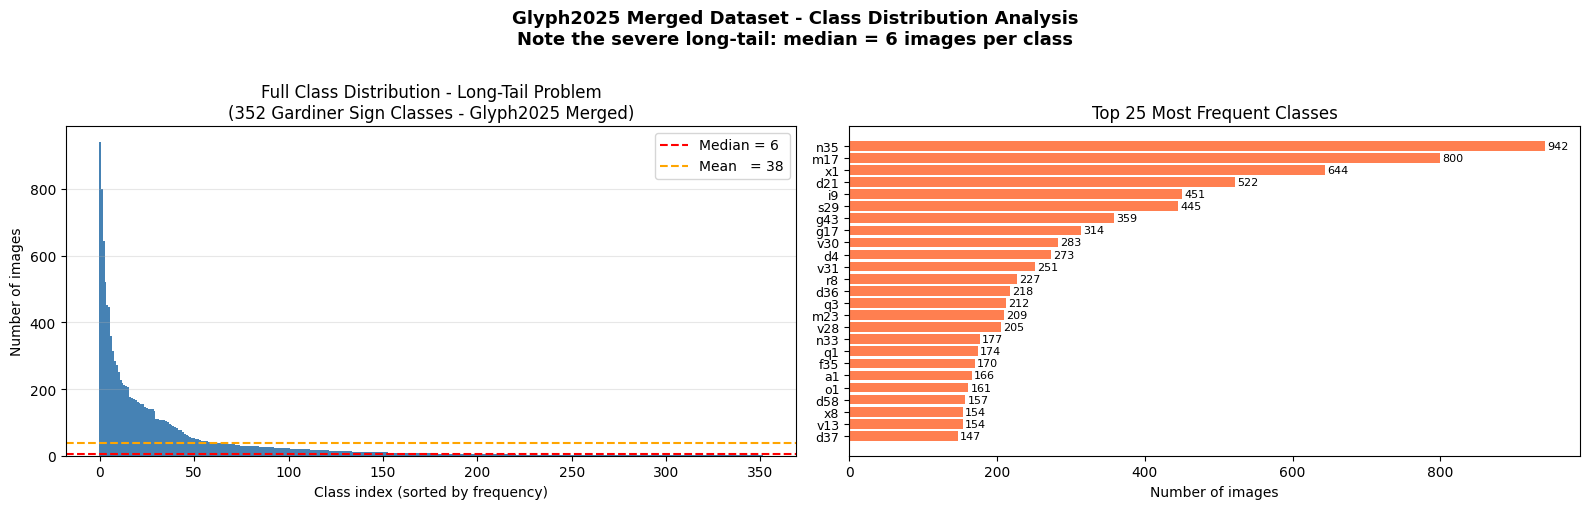

In [18]:
# --- Long-tail class distribution ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(class_counts)), class_counts.values, color='steelblue', width=1.0)
axes[0].axhline(class_counts.median(), color='red',    linestyle='--', lw=1.5,
                label=f'Median = {class_counts.median():.0f}')
axes[0].axhline(class_counts.mean(),   color='orange', linestyle='--', lw=1.5,
                label=f'Mean   = {class_counts.mean():.0f}')
axes[0].set_title('Full Class Distribution - Long-Tail Problem\n(352 Gardiner Sign Classes - Glyph2025 Merged)',
                  fontsize=12)
axes[0].set_xlabel('Class index (sorted by frequency)')
axes[0].set_ylabel('Number of images')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

top25 = class_counts.head(25)
axes[1].barh(range(len(top25)), top25.values[::-1], color='coral')
axes[1].set_yticks(range(len(top25)))
axes[1].set_yticklabels(top25.index[::-1], fontsize=9)
axes[1].set_title('Top 25 Most Frequent Classes', fontsize=12)
axes[1].set_xlabel('Number of images')
for i, v in enumerate(top25.values[::-1]):
    axes[1].text(v + 3, i, str(v), va='center', fontsize=8)

plt.suptitle('Glyph2025 Merged Dataset - Class Distribution Analysis\n'
             f'Note the severe long-tail: median = {class_counts.median():.0f} images per class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Image 1:
The red line (Median = 6) vs orange line (Mean = 38) tells us:

Half of all our classes have only 6 images or fewer. This is the long-tail problem -> a tiny number of classes dominate while the majority are starved of data. This is exactly why we perform Weighted Random Sampling.

Image 2: These classes are all high frequency phonograms - signs that appear constantly in Egyptian texts, so naturally they have the most images in the dataset.

# **<span style="color: #c9a84c;"> 𓃒  Section 3 - Sample Images & Annotations</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We visualise actual images with their Gardiner code labels across the merged <b style="color: #f0d080;">Glyph2025</b> dataset.</span>

**𓇻  Figure 2 - Domain Shift:**
The sample grid shows the same sign classes appearing on completely different physical supports
- Carved stone relief (grey/beige tones)
- Painted stone (golden/warm tones)
- Papyrus paintings (colorful, red/brown backgrounds)
- Black silhouette drawings (white background)


**𓇻  Figure 3 - Scribal Variability:**
Each row shows 8 different instances of the same sign (N35, M17, G17). The same sign looks dramatically different depending on which scribe drew it and what tool they used. This is scribal variability - even on the same material, no two scribes drew identically.

Both problems together explain why pixel-only classification fails and why contextual understanding is essential.



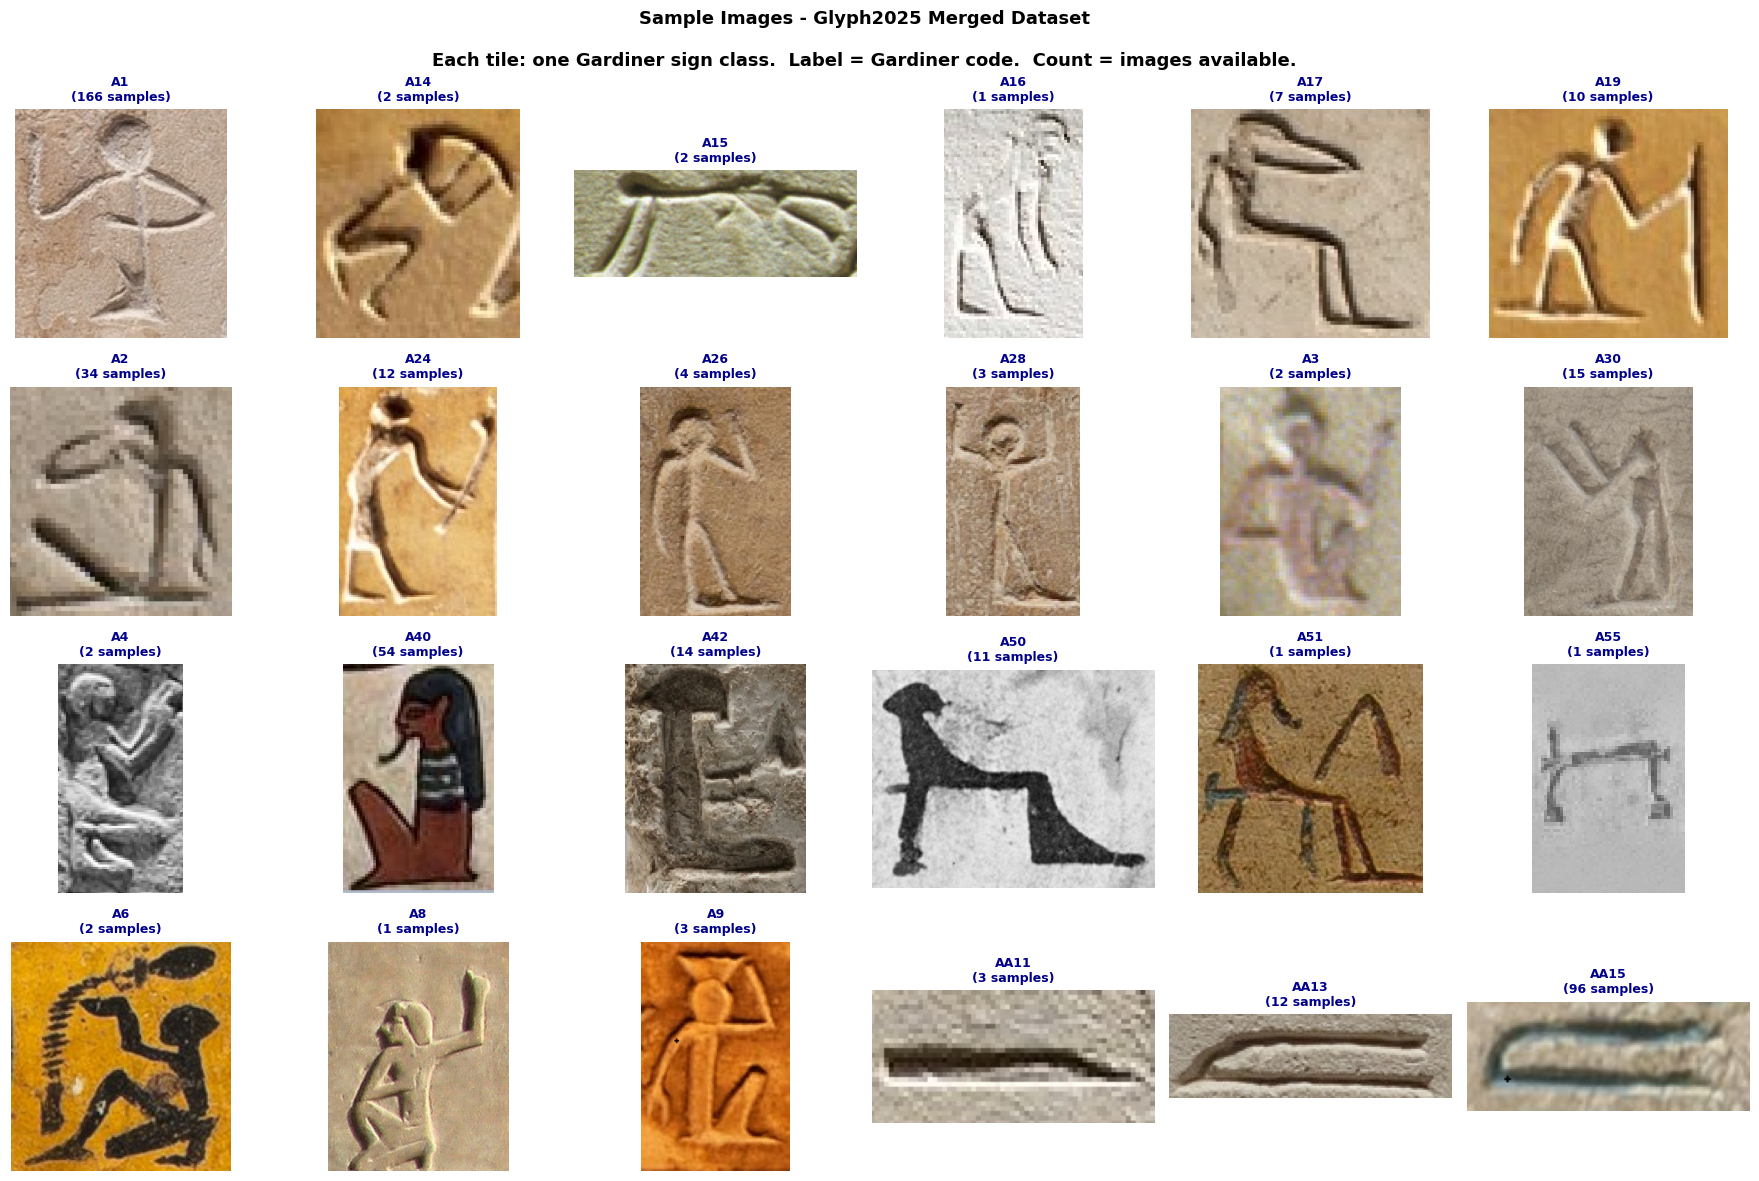

Saved: fig2_sample_images.png


In [19]:
# --- Sample grid: one image per class (first 24 classes) ----------------------
sample_classes = sorted(df_all['label'].unique())[:24]

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    row = df_all[df_all['label'] == cls].iloc[0]
    n   = len(df_all[df_all['label'] == cls])
    try:
        img = Image.open(row['path']).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(f'{cls.upper()}\n({n} samples)', fontsize=9,
                          fontweight='bold', color='darkblue')
    except:
        axes[i].text(0.5, 0.5, 'load\nerror', ha='center', va='center',
                     transform=axes[i].transAxes, color='red')
    axes[i].axis('off')

plt.suptitle('Sample Images - Glyph2025 Merged Dataset\n\n'
             'Each tile: one Gardiner sign class.  Label = Gardiner code.  '
             'Count = images available.',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_sample_images.png')

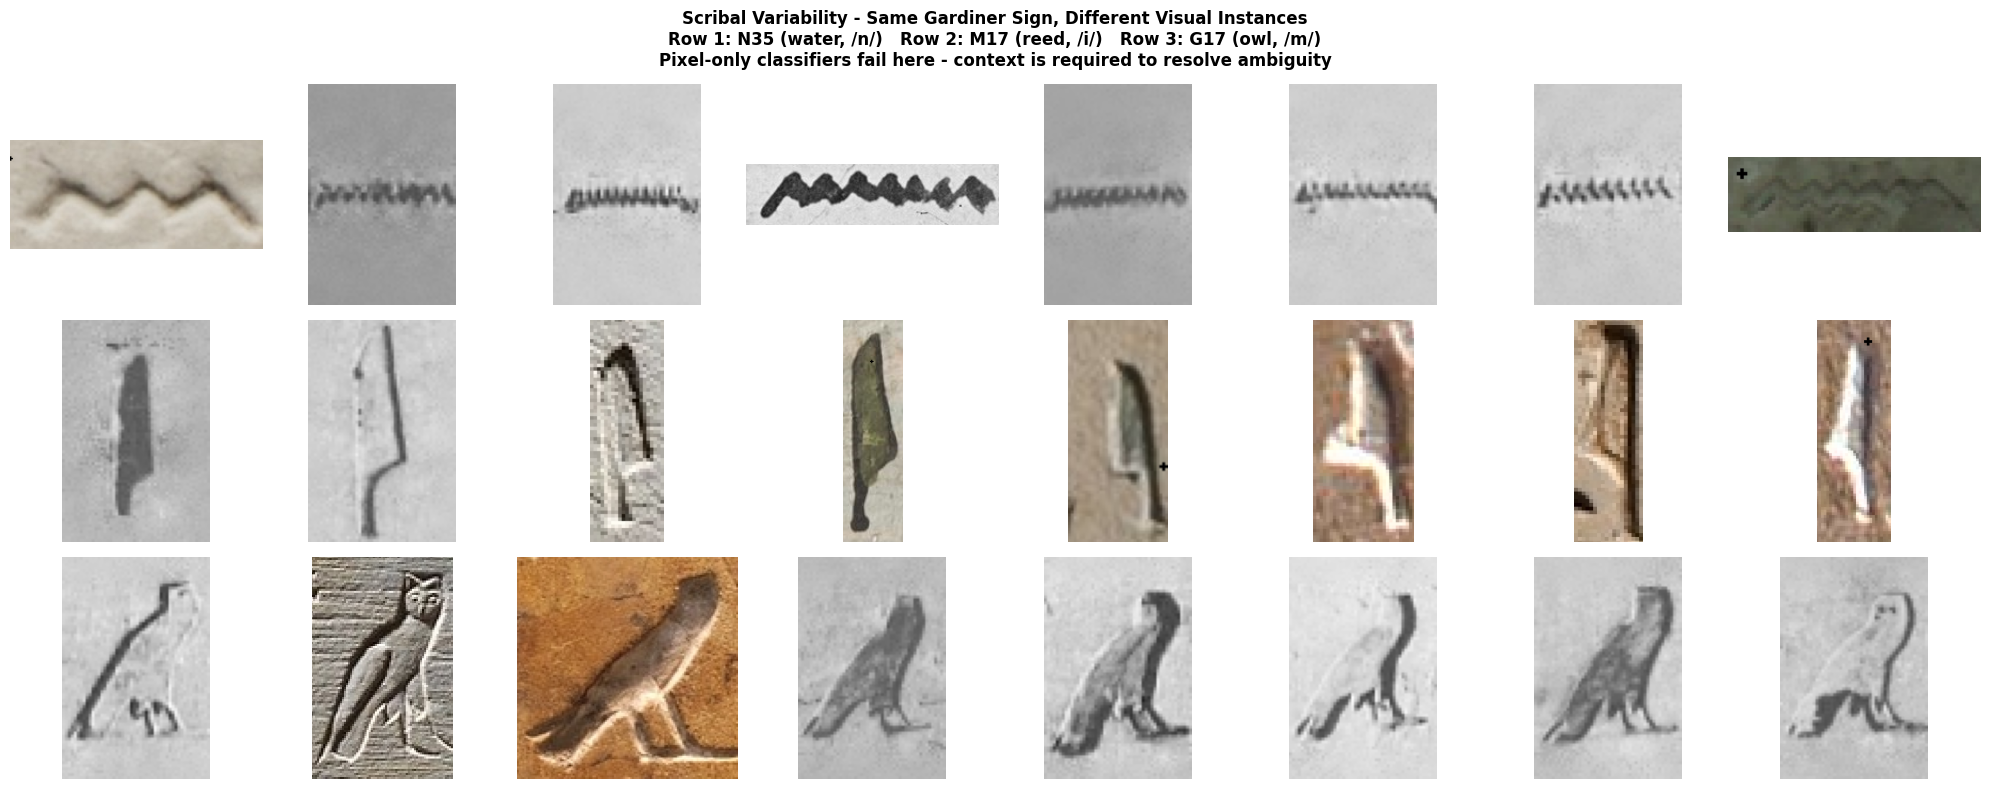

Saved: fig3_scribal_variability.png


In [20]:
# --- Scribal variability: same class, 8 different instances -------------------
# n35 = water (phoneme /n/), m17 = reed (phoneme /i/), g17 = owl (phoneme /m/)

demo_classes = ['n35', 'm17', 'g17']
fig, axes = plt.subplots(3, 8, figsize=(20, 8))

for row_i, cls in enumerate(demo_classes):
    samples = df_all[df_all['label'] == cls]['path'].tolist()
    random.shuffle(samples)
    for col_i in range(8):
        ax = axes[row_i, col_i]
        if col_i < len(samples):
            try:
                img = Image.open(samples[col_i]).convert('RGB')
                ax.imshow(img)
                if col_i == 0:
                    ax.set_ylabel(f'{cls.upper()}\n({len(samples)} imgs)',
                                  fontsize=10, fontweight='bold',
                                  rotation=0, labelpad=80, va='center')
            except:
                ax.text(0.5, 0.5, 'err', ha='center', va='center',
                        transform=ax.transAxes)
        else:
            ax.set_visible(False)
        ax.axis('off')

plt.suptitle('Scribal Variability - Same Gardiner Sign, Different Visual Instances\n'
             'Row 1: N35 (water, /n/)   Row 2: M17 (reed, /i/)   Row 3: G17 (owl, /m/)\n'
             'Pixel-only classifiers fail here - context is required to resolve ambiguity',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_scribal_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_scribal_variability.png')

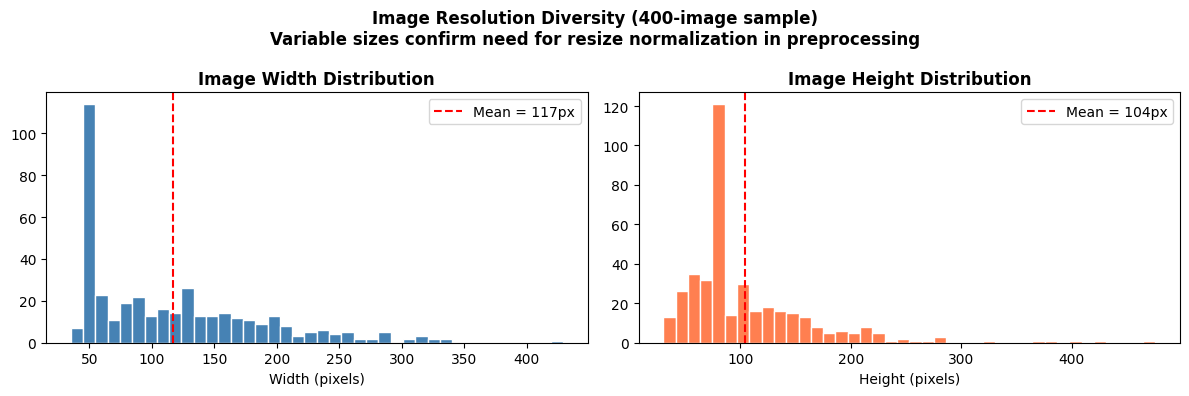

Width  — mean: 117px  std: 72px
Height — mean: 104px  std: 62px


In [21]:
# --- Image resolution diversity -----------------------------------------------
sample_paths = df_all['path'].sample(400, random_state=42).tolist()
widths, heights = [], []
for p in sample_paths:
    try:
        w, h = Image.open(p).size
        widths.append(w); heights.append(h)
    except:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, label, color in [
    (axes[0], widths,  'Width',  'steelblue'),
    (axes[1], heights, 'Height', 'coral')
]:
    ax.hist(data, bins=40, color=color, edgecolor='white')
    ax.axvline(np.mean(data), color='red', linestyle='--',
               label=f'Mean = {np.mean(data):.0f}px')
    ax.set_title(f'Image {label} Distribution', fontweight='bold')
    ax.set_xlabel(f'{label} (pixels)')
    ax.legend()

plt.suptitle('Image Resolution Diversity (400-image sample)\n'
             'Variable sizes confirm need for resize normalization in preprocessing',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Width  - mean: {np.mean(widths):.0f}px  std: {np.std(widths):.0f}px')
print(f'Height - mean: {np.mean(heights):.0f}px  std: {np.std(heights):.0f}px')

# **<span style="color: #c9a84c;">𓅝  Section 4 - Train / Validation / Test Split</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

**Strategy:** Stratified 70 / 15 / 15 split on the full merged **Glyph2025** dataset.  
Classes with fewer than 7 samples are excluded (minimum required for stratified splitting across all three sets).  
We explicitly verify **zero data leakage** - no image path appears in more than one split.

**Comparison:**
| Model | Dataset | Classes | Split |
|---|---|---|---|
| Glyphnet [2] | Franken 4,210 imgs | 40 | 60/40 |
| **Ours** | **Glyph2025 13,287 imgs** | **352** | **70/15/15** |


In [22]:
MIN_SAMPLES = 7
valid_cls   = class_counts[class_counts >= MIN_SAMPLES].index
df_filtered = df_all[df_all['label'].isin(valid_cls)].reset_index(drop=True).copy()

print(f'Classes kept  (>= {MIN_SAMPLES} samples) : {len(valid_cls)}')
print(f'Classes dropped (too few)             : {df_all["label"].nunique() - len(valid_cls)}')
print(f'Images kept                           : {len(df_filtered):,}')
print(f'Images dropped                        : {len(df_all) - len(df_filtered)}')

# Encode labels to integer indices
label_to_idx = {lbl: i for i, lbl in enumerate(sorted(valid_cls))}
idx_to_label = {i: lbl for lbl, i in label_to_idx.items()}
df_filtered['label_idx'] = df_filtered['label'].map(label_to_idx)
NUM_CLASSES = len(label_to_idx)
print(f'\nFinal classes for training : {NUM_CLASSES}')

# Stratified 70 / 15 / 15
df_train, df_temp = train_test_split(df_filtered, test_size=0.30,
                                      stratify=df_filtered['label_idx'], random_state=42)
df_val, df_test   = train_test_split(df_temp,     test_size=0.50,
                                      stratify=df_temp['label_idx'],     random_state=42)

print(f'\nSplit Summary (Stratified 70/15/15)')
print(f'  Train : {len(df_train):>5,} images  ({100*len(df_train)/len(df_filtered):.1f}%)')
print(f'  Val   : {len(df_val):>5,} images  ({100*len(df_val)/len(df_filtered):.1f}%)')
print(f'  Test  : {len(df_test):>5,} images  ({100*len(df_test)/len(df_filtered):.1f}%)')

# --- Data leakage check -------------------------------------------------------
s_tr = set(df_train['path']); s_va = set(df_val['path']); s_te = set(df_test['path'])
print(f'\nData Leakage Check')
for name, a, b in [('Train vs Val', s_tr, s_va),
                    ('Train vs Test', s_tr, s_te),
                    ('Val vs Test',   s_va, s_te)]:
    overlap = len(a & b)
    status  = 'LEAKAGE DETECTED' if overlap else 'Clean - no overlap'
    print(f'  {name:16s}: {overlap} shared images -> {status}')

Classes kept  (>= 7 samples) : 176
Classes dropped (too few)             : 176
Images kept                           : 12,836
Images dropped                        : 451

Final classes for training : 176

Split Summary (Stratified 70/15/15)
  Train : 8,985 images  (70.0%)
  Val   : 1,925 images  (15.0%)
  Test  : 1,926 images  (15.0%)

Data Leakage Check
  Train vs Val    : 0 shared images -> Clean - no overlap
  Train vs Test   : 0 shared images -> Clean - no overlap
  Val vs Test     : 0 shared images -> Clean - no overlap


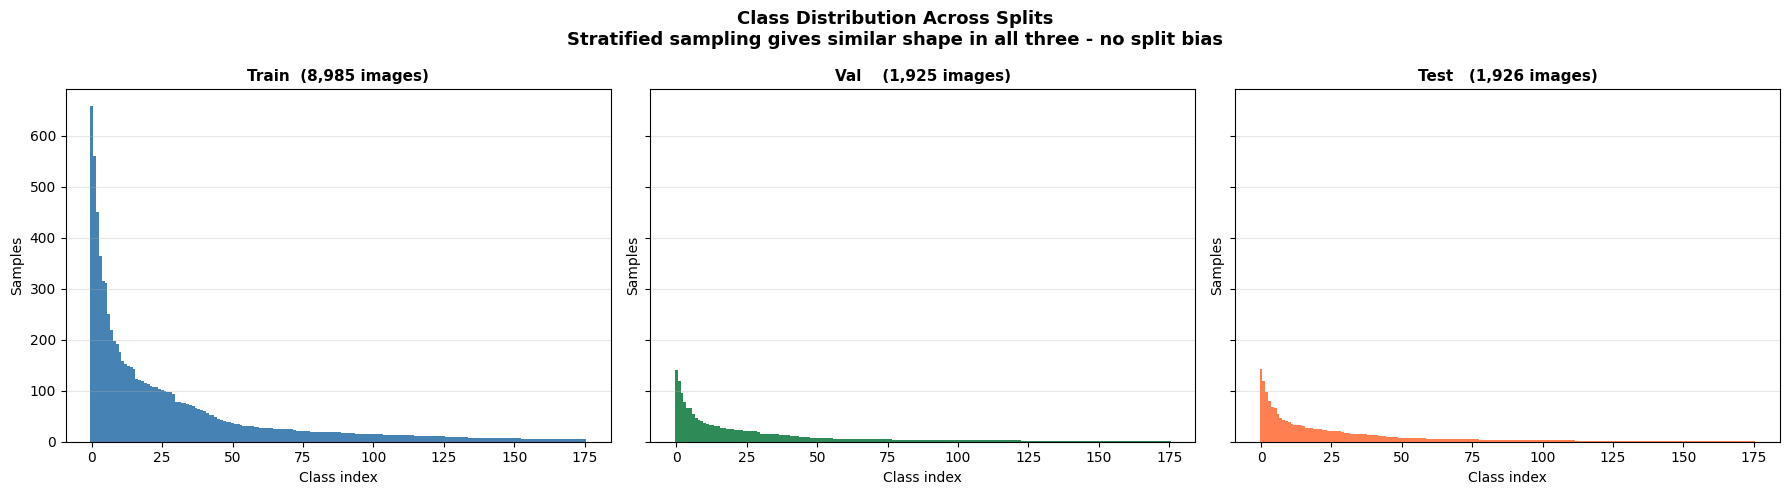

In [23]:
# --- Visualise split balance --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (df_s, title, color) in zip(axes, [
    (df_train, f'Train  ({len(df_train):,} images)', 'steelblue'),
    (df_val,   f'Val    ({len(df_val):,} images)',   'seagreen'),
    (df_test,  f'Test   ({len(df_test):,} images)',  'coral'),
]):
    cnts = df_s['label'].value_counts().sort_values(ascending=False)
    ax.bar(range(len(cnts)), cnts.values, color=color, width=1.0)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Class index')
    ax.set_ylabel('Samples')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution Across Splits\n'
             'Stratified sampling gives similar shape in all three - no split bias',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_split_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## **<span style="color: #c9a84c;">𓅮 Section 5 - Feature Enrichment (Novel Contribution)</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">**TA feedback:** Synthetic data adds no genuine diversity to a small dataset.
**Our solution:** Enrich each sample with linguistically-grounded metadata - directly analogous to POS tagging in low-resource Urdu NLP, which lifted accuracy from ~91% to 95%+.</span>

---

### <span style="color: #f0d080;">𓇼 What is Feature Enrichment?</span>

<span style="color: #e8d5a3;">Instead of generating fake images, we add three extra columns of information to each sample in our dataset. This gives the model linguistic context beyond raw pixels - the same way knowing a word is a *verb* helps an NLP model more than just knowing its spelling.</span>

---

### <span style="color: #f0d080;">𓇼 How did we decide on the three features?</span>

**<span style="color: #40E0D0;">Feature 1 - Functional Role</span>** <span style="color: #e8d5a3;">(phonogram / logogram / determinative)</span>

<span style="color: #e8d5a3;">This comes directly from the **Gardiner Sign List (1927)** - the standard Egyptological reference used worldwide. Alan Gardiner organized every hieroglyph into categories by letter prefix based on its linguistic function:</span>
- <span style="color: #a8d8a8;">Categories A-F (human/divine figures) -> **determinatives** - silent classifiers at word endings.</span>
- <span style="color: #a8d8a8;">Categories G-N (birds/plants/water) -> **phonograms** - represent sounds.</span>
- <span style="color: #a8d8a8;">Categories O-R (buildings/vessels) -> **logograms** - represent whole words.</span>

<span style="color: #e8d5a3;">We simply mapped Gardiner's own categories to these three labels.</span>

---

**<span style="color: #40E0D0;">Feature 2 - Phoneme Count</span>** <span style="color: #e8d5a3;">(uniliteral / biliteral / unknown)</span>

<span style="color: #e8d5a3;">This is derived from Egyptian grammar textbooks. The 24 uniliteral signs form the Egyptian consonantal alphabet and are universally documented. Common biliterals are also well established in published sign lists.</span>

- <span style="color: #a8d8a8;">**Uniliteral** - encodes 1 consonant (e.g. G17 owl = /m/) - hardcoded from known list</span>
- <span style="color: #a8d8a8;">**Biliteral** - encodes 2 consonants (e.g. D2 face = /hr/) - hardcoded from known list</span>
- <span style="color: #a8d8a8;">**Unknown** - sign not in our hardcoded lists - phoneme count not assumed</span>

> **Limitation:** Our uniliteral and biliteral lists are partial - they cover the most common signs but are not exhaustive. Signs not in either list are tagged as **unknown** rather than assumed to be triliteral. A complete phoneme mapping would require consultation with an Egyptologist or a published comprehensive sign list such as Hannig (2006).

---

**<span style="color: #40E0D0;">Feature 3 - Rarity Class</span>** <span style="color: #e8d5a3;">(common / mid / rare)</span>

<span style="color: #e8d5a3;">This is derived from **our own dataset statistics** computed in Section 2. By looking at the class distribution plot we set thresholds based on the natural breaks in the data:</span>
- <span style="color: #a8d8a8;">**Common** -> 100+ images - the dominant classes at the top of the distribution</span>
- <span style="color: #a8d8a8;">**Mid** -> 20-99 images - the middle portion of the curve</span>
- <span style="color: #a8d8a8;">**Rare** -> under 20 images - the long tail</span>

---

### <span style="color: #f0d080;">𓇼 Why does this help the model?</span>

<span style="color: #e8d5a3;">These features will be used as **auxiliary inputs** alongside the image. Consider this example:</span>

> <span style="color: #a8c4d8;">Two signs look visually similar - both are bird-shaped. But one is tagged as a **determinative** (silent, appears at word end) and the other as a **uniliteral phonogram** (represents /m/). The model can now use the tag to disambiguate what the pixels alone cannot distinguish.</span>

<span style="color: #e8d5a3;">This is the **Contextual Sign Disambiguation** described in our survey - implemented here as a data enrichment step rather than synthetic generation.</span>

| Feature | Source | Our contribution |
|---|---|---|
| Functional Role | Gardiner Sign List, 1927 | Mapped categories to labels |
| Phoneme Count | Egyptian grammar textbooks | Hardcoded known sign lists |
| Rarity Class | Our dataset statistics (Section 2) | Chose thresholds from distribution |

In [24]:
# --- Gardiner prefix -> functional role ---------------------------------------
# Based on Gardiner Sign List (1927), standard Egyptological reference
ROLE_MAP = {
    'a':'determinative', 'b':'determinative', 'c':'determinative',
    'd':'determinative', 'e':'determinative', 'f':'determinative',
    'g':'phonogram',     'h':'phonogram',     'i':'phonogram',
    'k':'phonogram',     'l':'phonogram',     'm':'phonogram',
    'n':'phonogram',     'o':'logogram',      'p':'logogram',
    'q':'logogram',      'r':'logogram',      's':'phonogram',
    't':'phonogram',     'u':'phonogram',     'v':'phonogram',
    'w':'phonogram',     'x':'logogram',      'y':'logogram',
    'z':'phonogram',     'aa':'phonogram'
}

# Known uniliterals (the 24-sign Egyptian consonantal alphabet)
UNILITERALS = {
    'g1','g17','g36','g43','d21','n35','m17','s29','t22',
    'v13','x1','z1','d46','f35','q3','v28','w11','d58',
    'h6','i9','i10','m12','n29','o34'
}
# Known biliterals (partial list of common ones)
BILITERALS = {
    'aa1','d2','d28','i10','m12','n14','r4','s34','v30','v31',
    'd36','d37','f31','g38','n33','n36','s21','v6','w17','w19'
}

def get_role(lbl):
    l = lbl.lower()
    for prefix in ['aa','a','b','c','d','e','f','g','h','i',
                   'k','l','m','n','o','p','q','r','s','t',
                   'u','v','w','x','y','z']:
        if l.startswith(prefix):
            return ROLE_MAP.get(prefix, 'unknown')
    return 'unknown'

def get_phoneme(lbl):
    l = lbl.lower()
    if l in UNILITERALS: return 'uniliteral'
    if l in BILITERALS:  return 'biliteral'
    return 'unknown'

def get_rarity(lbl, counts):
    n = counts.get(lbl, 0)
    if n >= 100: return 'common'
    if n >= 20:  return 'mid'
    return 'rare'

# --- Apply enrichment ----------------------------------------------------------
df_enriched = df_filtered.copy()
df_enriched['functional_role'] = df_enriched['label'].apply(get_role)
df_enriched['phoneme_count']   = df_enriched['label'].apply(get_phoneme)
df_enriched['rarity_class']    = df_enriched['label'].apply(
    lambda l: get_rarity(l, class_counts))
df_enriched['role_idx'] = df_enriched['functional_role'].map(
    {'phonogram':0, 'logogram':1, 'determinative':2, 'unknown':3})

print('Feature Enrichment Applied')
print()
print('BEFORE enrichment:')
print(df_filtered[['label']].head(6).to_string(index=False))
print()
print('AFTER enrichment:')
print(df_enriched[['label','functional_role','phoneme_count','rarity_class']].head(6).to_string(index=False))

Feature Enrichment Applied

BEFORE enrichment:
label
   a1
   a1
   a1
   a1
   a1
   a1

AFTER enrichment:
label functional_role phoneme_count rarity_class
   a1   determinative       unknown       common
   a1   determinative       unknown       common
   a1   determinative       unknown       common
   a1   determinative       unknown       common
   a1   determinative       unknown       common
   a1   determinative       unknown       common


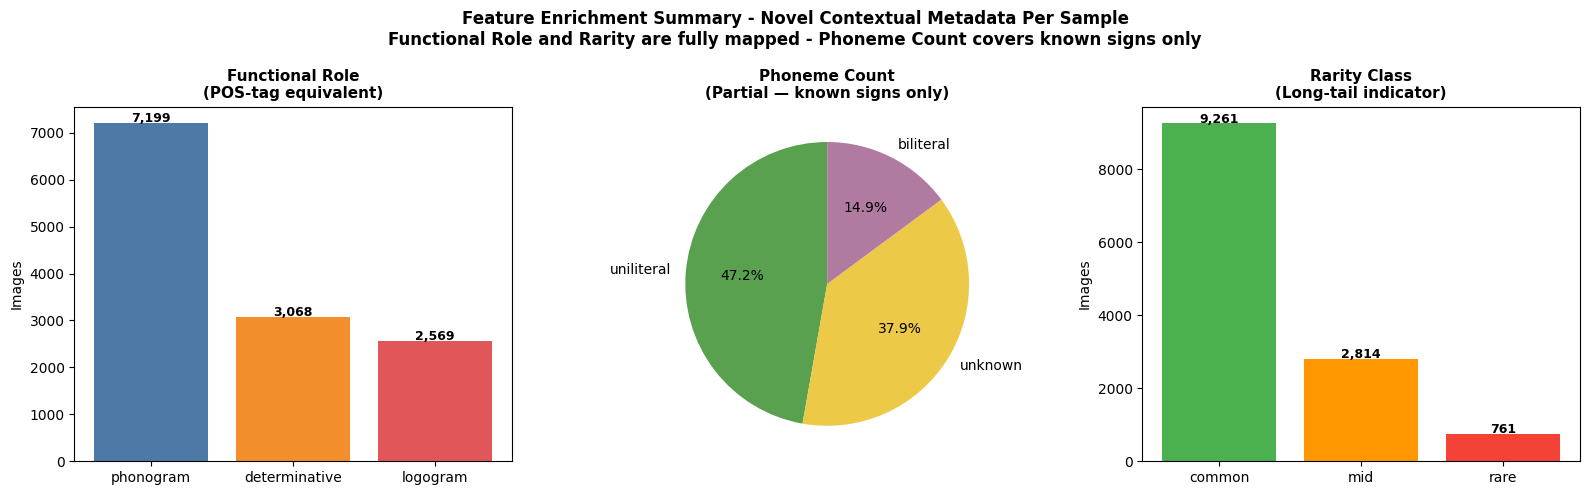

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Functional role
rc = df_enriched['functional_role'].value_counts()
bars = axes[0].bar(rc.index, rc.values, color=['#4e79a7','#f28e2b','#e15759','#aaa'])
axes[0].set_title('Functional Role\n(POS-tag equivalent)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Images')
for i,(k,v) in enumerate(rc.items()):
    axes[0].text(i, v+20, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

# Phoneme count
pc = df_enriched['phoneme_count'].value_counts()
axes[1].pie(pc.values, labels=pc.index, autopct='%1.1f%%',
            colors=['#59a14f','#edc948','#b07aa1'], startangle=90)
axes[1].set_title('Phoneme Count\n(Partial - known signs only)', fontweight='bold', fontsize=11)

# Rarity
rr = df_enriched['rarity_class'].value_counts()
axes[2].bar(rr.index, rr.values, color=['#4caf50','#ff9800','#f44336'])
axes[2].set_title('Rarity Class\n(Long-tail indicator)', fontweight='bold', fontsize=11)
axes[2].set_ylabel('Images')
for i,(k,v) in enumerate(rr.items()):
    axes[2].text(i, v+20, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Feature Enrichment Summary - Novel Contextual Metadata Per Sample\n'
             'Functional Role and Rarity are fully mapped - Phoneme Count covers known signs only',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_enrichment.png', dpi=150, bbox_inches='tight')
plt.show()

## **<span style="color: #c9a84c;">⚖ Section 6 - Class Imbalance: Weighted Random Sampling</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #e8d5a3;">The merged Glyph2025 dataset is severely imbalanced - `n35` has 650+ images while the rarest classes have only 7. Without correction, the model would spend 93x more time learning `n35` than any rare class, effectively ignoring the long tail entirely.</span>

<span style="color: #e8d5a3;">We address this using **PyTorch WeightedRandomSampler** - each image is assigned a sampling weight of **1/class_frequency**. Rare classes are sampled more frequently during training so the model is exposed to them rather than ignoring them entirely.</span>



WeightedRandomSampler created
  Rarest class upsampling  : x0.2
  Most common class weight : 0.00152


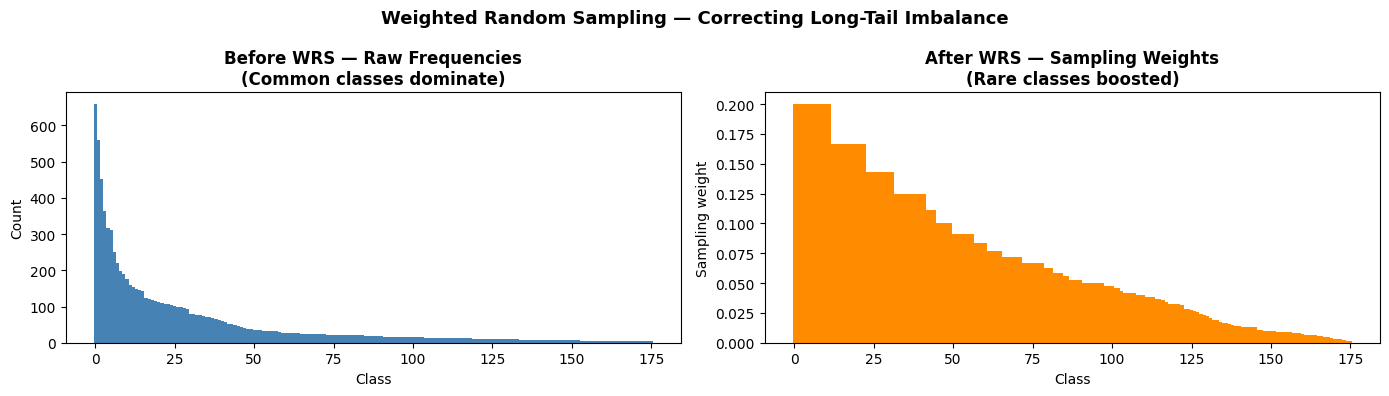

In [26]:
# Re-apply split on enriched dataframe
df_enriched['label_idx'] = df_enriched['label'].map(label_to_idx)
df_tr, df_tmp = train_test_split(df_enriched, test_size=0.30,
                                  stratify=df_enriched['label_idx'], random_state=42)
df_va, df_te  = train_test_split(df_tmp, test_size=0.50,
                                  stratify=df_tmp['label_idx'], random_state=42)

train_labels     = df_tr['label_idx'].values
class_sample_cnt = np.bincount(train_labels, minlength=NUM_CLASSES)
weight_per_class = 1.0 / (class_sample_cnt + 1e-6)
sample_weights   = weight_per_class[train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_labels),
    replacement=True
)
print(f'WeightedRandomSampler created')
print(f'  Rarest class upsampling  : x{weight_per_class.max():.1f}')
print(f'  Most common class weight : {weight_per_class.min():.5f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(NUM_CLASSES), sorted(class_sample_cnt, reverse=True),
            color='steelblue', width=1.0)
axes[0].set_title('Before WRS - Raw Frequencies\n(Common classes dominate)', fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')

axes[1].bar(range(NUM_CLASSES), sorted(weight_per_class, reverse=True),
            color='darkorange', width=1.0)
axes[1].set_title('After WRS - Sampling Weights\n(Rare classes boosted)', fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Sampling weight')

plt.suptitle('Weighted Random Sampling - Correcting Long-Tail Imbalance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_wrs.png', dpi=150, bbox_inches='tight')
plt.show()

# **<span style="color: #c9a84c;">𓅨 Section 7 - POC: Baseline Visual Classifier</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

We fine-tune **ConvNeXt-Tiny** (ImageNet pretrained) on the full merged **Glyph2025** dataset.

**Why ConvNeXt over Glyphnet?**  
Glyphnet is a custom shallow CNN trained on only 40 classes (~79% accuracy reported).  
ConvNeXt-Tiny uses modern depthwise convolutions and layer normalization - significantly stronger.  
We train on **352 classes** from the merged dataset - nearly 9x more classes than Glyphnet.




In [27]:
class HieroglyphDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')
        except:
            img = Image.new('RGB', (64, 64), (128, 128, 128))
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['label_idx']), dtype=torch.long)


IMG_SIZE   = 224
BATCH_SIZE = 64

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = HieroglyphDataset(df_tr, transform=train_tf)
val_ds   = HieroglyphDataset(df_va, transform=eval_tf)
test_ds  = HieroglyphDataset(df_te, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2)

print(f'DataLoaders ready | Classes: {NUM_CLASSES} | '
      f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

DataLoaders ready | Classes: 176 | Train batches: 141 | Val: 31 | Test: 31


In [28]:
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model            : ConvNeXt-Tiny (ImageNet pretrained)')
print(f'Total params     : {total_p:,}')
print(f'Trainable params : {train_p:,}')
print(f'Output classes   : {NUM_CLASSES}')

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 153MB/s] 


Model            : ConvNeXt-Tiny (ImageNet pretrained)
Total params     : 27,955,472
Trainable params : 27,955,472
Output classes   : 176


In [29]:
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


NUM_EPOCHS = 40  # ← increase to 30-50 for final training
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history  = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val = 0.0
best_wts = None

print(f'Phase 1 Training - ConvNeXt-Tiny | {NUM_CLASSES} classes | Device: {DEVICE}\n')
print(f'{"Epoch":<7} {"Tr Loss":<11} {"Tr Acc%":<11} {"Va Loss":<11} {"Va Acc%":<11} {"Best%"}')
print('-' * 60)

for ep in range(1, NUM_EPOCHS + 1):
    tr_l, tr_a = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    va_l, va_a = run_epoch(model, val_loader,   optimizer, criterion, DEVICE, train=False)
    scheduler.step()
    history['train_loss'].append(tr_l); history['train_acc'].append(tr_a)
    history['val_loss'].append(va_l);   history['val_acc'].append(va_a)
    if va_a > best_val:
        best_val = va_a
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    print(f'{ep:<7} {tr_l:<11.4f} {tr_a*100:<11.2f} {va_l:<11.4f} {va_a*100:<11.2f} {best_val*100:.2f}')

print(f'\nBest validation accuracy : {best_val*100:.2f}%')

Phase 1 Training — ConvNeXt-Tiny | 176 classes | Device: cuda

Epoch   Tr Loss     Tr Acc%     Va Loss     Va Acc%     Best%
------------------------------------------------------------
1       2.1788      61.90       0.5578      87.06       87.06
2       0.2686      94.77       0.3504      90.34       90.34
3       0.1540      96.51       0.2825      92.16       92.16
4       0.0891      98.01       0.2598      93.25       93.25
5       0.0800      98.11       0.2843      92.05       93.25
6       0.0518      98.71       0.3589      90.65       93.25
7       0.0640      98.22       0.3192      92.05       93.25
8       0.0729      98.31       0.4110      89.19       93.25
9       0.0535      98.62       0.3187      91.58       93.25
10      0.0440      98.94       0.3114      92.26       93.25
11      0.0366      99.10       0.3201      92.10       93.25
12      0.0290      99.24       0.3156      92.00       93.25
13      0.0286      99.33       0.2584      94.08       94.08
14      

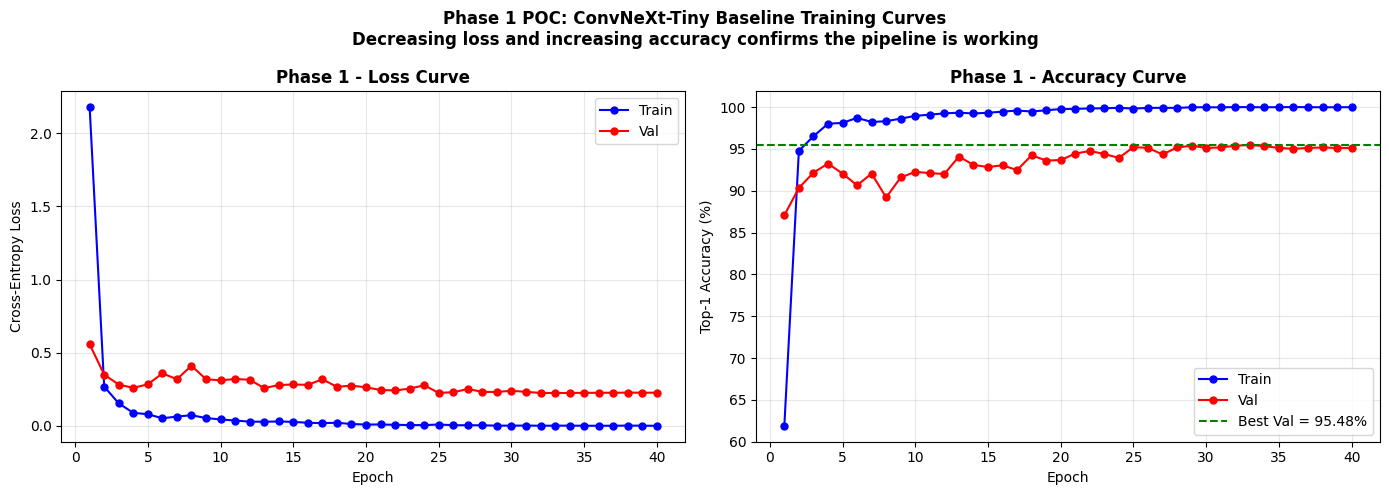

In [30]:
# --- Learning curves ----------------------------------------------------------
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', ms=5, label='Train')
axes[0].plot(epochs, history['val_loss'],   'r-o', ms=5, label='Val')
axes[0].set_title('Phase 1 - Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=5, label='Train')
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=5, label='Val')
axes[1].axhline(best_val*100, color='green', linestyle='--', lw=1.5,
                label=f'Best Val = {best_val*100:.2f}%')
axes[1].set_title('Phase 1 - Accuracy Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Top-1 Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Phase 1 POC: ConvNeXt-Tiny Baseline Training Curves\n'
             'Decreasing loss and increasing accuracy confirms the pipeline is working',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# --- Final test evaluation -----------------------------------------------------
if best_wts:
    model.load_state_dict(best_wts)

test_loss, test_acc = run_epoch(model, test_loader, None, criterion, DEVICE, train=False)

print('=' * 58)
print('  PHASE 1 - FINAL TEST SET RESULTS')
print('=' * 58)
print(f'  Test Loss            : {test_loss:.4f}')
print(f'  Test Accuracy        : {test_acc*100:.2f}%')
print(f'  Best Val Accuracy    : {best_val*100:.2f}%')
print(f'  Glyphnet [2] baseline: ~79.0% (40 classes, 4,210 images)')
print(f'  Our task is harder   : {NUM_CLASSES} classes, {len(df_filtered):,} images')
print('=' * 58)
print()
print('Next phases:')
print('  Phase 2 - Add functional role as auxiliary input  -> target: +3 to 5%')
print('  Phase 3 - Multi-Head Attention over sequences     -> target: +5 to 10% + BLEU/WER')

  PHASE 1 - FINAL TEST SET RESULTS
  Test Loss            : 0.2121
  Test Accuracy        : 95.48%
  Best Val Accuracy    : 95.48%
  Glyphnet [2] baseline: ~79.0% (40 classes, 4,210 images)
  Our task is harder   : 176 classes, 12,836 images

Next phases:
  Phase 2 - Add functional role as auxiliary input  -> target: +3 to 5%
  Phase 3 - Multi-Head Attention over sequences     -> target: +5 to 10% + BLEU/WER


# **<span style="color: #c9a84c;">𓅣 Section 8 - Multi-Phase Training Roadmap</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

This table will be updated in each subsequent deliverable.  
The key story: **each phase adds one type of information, and accuracy should increase each time.**


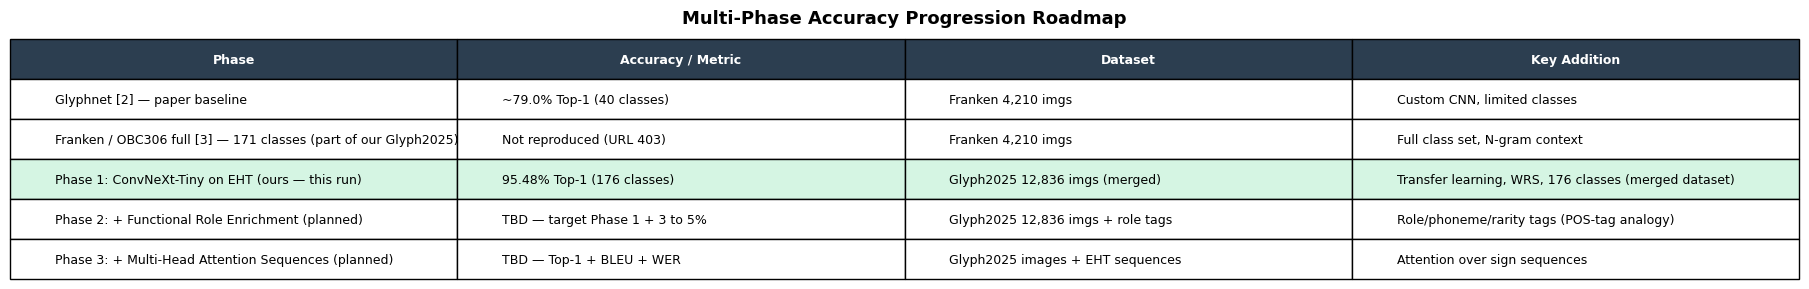

,Phase,Accuracy / Metric,Dataset,Key Addition
0,Glyphnet [2] — paper baseline,~79.0% Top-1 (40 classes),"Franken 4,210 imgs","Custom CNN, limited classes"
1,Franken / OBC306 full [3] — 171 classes (part ...,Not reproduced (URL 403),"Franken 4,210 imgs","Full class set, N-gram context"
2,Phase 1: ConvNeXt-Tiny on EHT (ours — this run),95.48% Top-1 (176 classes),"Glyph2025 12,836 imgs (merged)","Transfer learning, WRS, 176 classes (merged da..."
3,Phase 2: + Functional Role Enrichment (planned),TBD — target Phase 1 + 3 to 5%,"Glyph2025 12,836 imgs + role tags",Role/phoneme/rarity tags (POS-tag analogy)
4,Phase 3: + Multi-Head Attention Sequences (pla...,TBD — Top-1 + BLEU + WER,Glyph2025 images + EHT sequences,Attention over sign sequences


In [32]:
df_roadmap = pd.DataFrame({
    'Phase': [
        'Glyphnet [2] - paper baseline',
        'Franken / OBC306 full [3] - 171 classes (part of our Glyph2025)',
        'Phase 1: ConvNeXt-Tiny on EHT (ours - this run)',
        'Phase 2: + Functional Role Enrichment (planned)',
        'Phase 3: + Multi-Head Attention Sequences (planned)'
    ],
    'Accuracy / Metric': [
        '~79.0% Top-1 (40 classes)',
        'Not reproduced (URL 403)',
        f'{test_acc*100:.2f}% Top-1 ({NUM_CLASSES} classes)',
        'TBD - target Phase 1 + 3 to 5%',
        'TBD - Top-1 + BLEU + WER'
    ],
    'Dataset': [
        'Franken 4,210 imgs',
        'Franken 4,210 imgs',
        f'Glyph2025 {len(df_filtered):,} imgs (merged)',
        f'Glyph2025 {len(df_filtered):,} imgs + role tags',
        'Glyph2025 images + EHT sequences'
    ],
    'Key Addition': [
        'Custom CNN, limited classes',
        'Full class set, N-gram context',
        f'Transfer learning, WRS, {NUM_CLASSES} classes (merged dataset)',
        'Role/phoneme/rarity tags (POS-tag analogy)',
        'Attention over sign sequences'
    ]
})

fig, ax = plt.subplots(figsize=(18, 3))
ax.axis('off')
tbl = ax.table(cellText=df_roadmap.values, colLabels=df_roadmap.columns,
               cellLoc='left', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 2.4)
for j in range(len(df_roadmap.columns)):
    tbl[0, j].set_facecolor('#2c3e50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[3, j].set_facecolor('#d5f5e3')   # highlight current phase
plt.title('Multi-Phase Accuracy Progression Roadmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig9_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()
display(df_roadmap)

# **<span style="color: #c9a84c;">𓃘 Section 9 - Save Artifacts</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">


In [33]:
df_enriched.to_csv('dataset_enriched.csv', index=False)
df_tr.to_csv('split_train.csv', index=False)
df_va.to_csv('split_val.csv',   index=False)
df_te.to_csv('split_test.csv',  index=False)
with open('label_map.json',    'w') as f: json.dump(label_to_idx, f, indent=2)
with open('idx_to_label.json', 'w') as f: json.dump(idx_to_label, f, indent=2)
if best_wts:
    torch.save(best_wts, 'phase1_convnext_best.pth')

print('Artifacts saved:')
for fname in ['dataset_enriched.csv','split_train.csv','split_val.csv','split_test.csv',
              'label_map.json','idx_to_label.json','phase1_convnext_best.pth']:
    status = 'OK' if Path(fname).exists() else 'MISSING'
    print(f'  [{status}]  {fname}')
print()
print('=== DELIVERABLE 2 COMPLETE ===')

Artifacts saved:
  [OK]  dataset_enriched.csv
  [OK]  split_train.csv
  [OK]  split_val.csv
  [OK]  split_test.csv
  [OK]  label_map.json
  [OK]  idx_to_label.json
  [OK]  phase1_convnext_best.pth

=== DELIVERABLE 2 COMPLETE ===
